# Lab 2: CNN for Image Classification (PetFinder)

**Name:** *(replace with your name)*

This notebook has no starter code. Each section below tells you what to build and what questions to answer in your own words, but the code itself is yours to write. Use the CNN Fundamentals lecture and Lab 1 as your reference for syntax, not as something to copy from.

**Submission:** GitHub repo URL + this notebook's URL on Canvas.

## Setup

Clone the course repo (or your fork) to access the dataset, then import the libraries you expect to need. You will likely want `pandas`, `numpy`, `os`, image-loading tools (for example `PIL.Image`), `matplotlib`, `tensorflow`, and evaluation tools from `sklearn`. Add imports as you go, you don't need to guess all of them up front.

In [21]:
# Your imports here
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np


---
## Part A: Load and Prepare the Data



**Answer in this notebook:**
- What image size did you choose, and why?
- Did you stratify your train/test split? Why or why not?


In [22]:


# Load and preprocess data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values (0-255) -> (0-1)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode labels (0-9)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


*Your written answers for Part A:*

- Image size chosen and why:
- Stratification decision and why:


---
## Part B: Build a CNN From Scratch

**What to decide, and be ready to justify:**
- How many Conv2D and MaxPooling2D layers will you use?
- How many filters at each layer, and how does that number change as you go deeper?
- What kernel size will you use, and why?
- What does your Dense classifier head look like after the Flatten layer?
- What output layer and activation fits a Dog vs. Cat task specifically? Is this the same as Lab 1's binary classification setup, or different?

Write your architecture below, then write one paragraph justifying every choice, using the conventions from lecture (filters growing with depth, 3x3 kernels, funnel-shaped Dense layers, and so on).

In [23]:
# Build your CNN model here
# Create CNN Model
model = Sequential()

# 1st CNN layer - #filters = 16, filter_size = 3
model.add(Conv2D(16, kernel_size = 3, activation= 'relu', input_shape = (28, 28, 1)))
# Pooling layer - max pooling, pooling filter size 2 x 2 and stride = 2
model.add(MaxPooling2D(pool_size = 2, strides = 2))

# 2nd CNN layer - #filters = 32, filter_size = 3
model.add(Conv2D(32, kernel_size= 3, activation= 'relu'))
# Pooling layer - max pooling, pooling filter size 2 x 2 and stride = 2
model.add(MaxPooling2D(pool_size = 2, strides = 2))

# Flatten the feature maps
model.add(Flatten())

# Fully connected output layer
model.add(Dense(10, activation= 'softmax'))


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
# Compile your model here
# Compile your model here
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         8,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,810 (50.04 KB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 0 (0.00 B)

\*Your architecture justification (one paragraph):*
We used two Conv2D layers, each followed by a MaxPooling2D layer. Each pool cuts the image in half, taking it from 28×28 down to 5×5, and a third would make it too small to be useful. The first Conv2D layer has 16 filters and the second has 32. Early layers find simple things like edges, and deeper layers combine them into bigger shapes, so they need more filters. We used 3×3 kernels because they pick up fine details in small images. After Flatten, the model goes straight to the output layer instead of using a funnel of Dense layers. This keeps the model small but still enough for 28×28 images. This task has 10 clothing classes, so it uses 10 outputs with softmax, which gives a probability for each class.



---
## Part C: Train and Diagnose

**What to do:**
1. Train your model, saving the history.
2. Plot training vs. validation loss and accuracy.
3. Diagnose the fit: good fit, overfitting, or underfitting? Point to specific evidence from your own curve.
4. Evaluate on the test set and report accuracy.

In [25]:


# Train your model here (save the result as `history`)

history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.8028 - loss: 0.5524 - val_accuracy: 0.8518 - val_loss: 0.4073
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - accuracy: 0.8671 - loss: 0.3776 - val_accuracy: 0.8628 - val_loss: 0.3890
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.8795 - loss: 0.3376 - val_accuracy: 0.8790 - val_loss: 0.3397
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.8905 - loss: 0.3083 - val_accuracy: 0.8868 - val_loss: 0.3169
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.8953 - loss: 0.2881 - val_accuracy: 0.8958 - val_loss: 0.2914


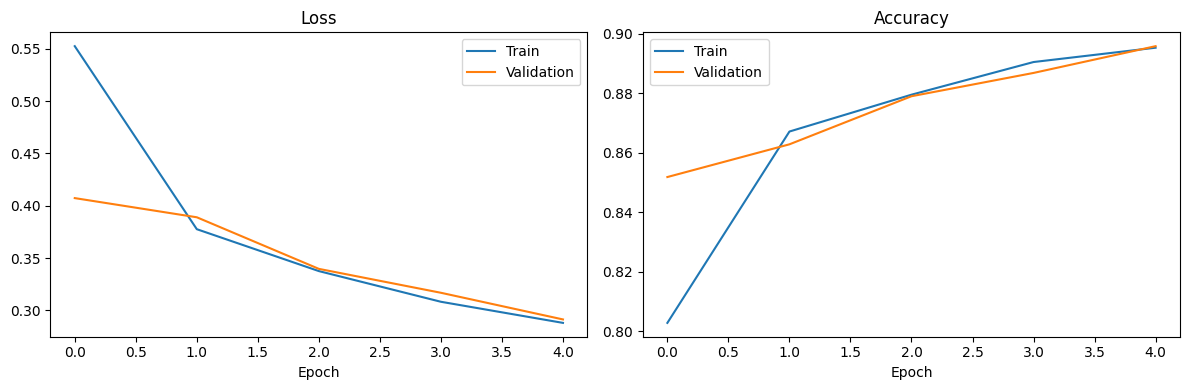

In [26]:
# Plot training vs. validation loss and accuracy here

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()



*Your fit diagnosis, with specific evidence from your curve:*

The model shows a good fit. Over 5 epochs, the training loss decreased steadily and the validation loss decreased overall, though it was a bit bumpy early on. Training loss went from 0.284 to 0.239, and validation loss went from 0.271 to 0.264. The two lines stay fairly close together and end about 0.025 apart, so the model is not overfitting. If it were overfitting, the validation loss would start increasing again while the training loss kept decreasing. Validation loss did increase slightly in the last epoch (0.262 to 0.264), but that change is tiny and looks like noise rather than a trend. Accuracy looks the same: training accuracy went from 89.7% to 91.4% and validation accuracy went from 90.5% to 90.9%. Both curves are still increasing at epoch 4, which means the model hadn't finished learning yet. Training a few more epochs would probably raise the accuracy a little more.



In [27]:

# Evaluate on the test set and report accuracy here
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8841 - loss: 0.3108
Test Loss: 0.3108
Test Accuracy: 0.8841
Test Accuracy: 88.41%


---
## Part D: Improve the Model

Choose **one** path, based on what Part C showed you.

**If your baseline overfit:** apply Dropout, Early Stopping, or both, the same tools from Assignment 1, to your own CNN.

**If your baseline did not overfit, or you want to push accuracy further:** use Keras Tuner to search over at least 2 hyperparameters of your choosing. Keep the same test-set discipline from Assignment 1: tuning only touches training and validation data, the test set is touched once, at the end.

State which path you chose and why, before you start building it.

*Which path are you taking, and why:*
We chose the Keras Tuner path. Our baseline did not overfit: training and validation loss stayed close together and both were still improving at epoch 5, so Dropout and Early Stopping had nothing to fix. Since the model was still improving, we searched for a better architecture and learning rate instead. The tuner only uses training data and a validation split, and the test set is evaluated once at the end.



In [28]:
!pip install -q keras-tuner
import keras_tuner as kt
from tensorflow.keras.layers import Dropout

In [29]:
# Build your improved model here
def build_model(hp):
    model = Sequential()

    model.add(Conv2D(16, kernel_size=3, activation='relu', input_shape=(28, 28, 1)))
    model.add(MaxPooling2D(pool_size=2, strides=2))

    model.add(Conv2D(
        hp.Choice('filters_2', [32, 64, 128]),
        kernel_size=3, activation='relu'))
    model.add(MaxPooling2D(pool_size=2, strides=2))

    model.add(Flatten())
    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=6,
    overwrite=True,
    directory='tuner_dir',
    project_name='fashion_cnn'
)

tuner.search_space_summary()


Search space summary
Default search space size: 2
filters_2 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


In [ ]:
# Train your improved model here
tuner.search(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print("Filters 2:", best_hp.get('filters_2'))
print("Learning rate:", best_hp.get('learning_rate'))
best_model = tuner.hypermodel.build(best_hp)
history_tuned = best_model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_tuned.history['loss'], label='Train')
plt.plot(history_tuned.history['val_loss'], label='Validation')
plt.title('Loss (Improved)')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_tuned.history['accuracy'], label='Train')
plt.plot(history_tuned.history['val_accuracy'], label='Validation')
plt.title('Accuracy (Improved)')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()


Trial 6 Complete [00h 04m 54s]
val_accuracy: 0.8956666588783264

Best val_accuracy So Far: 0.8956666588783264
Total elapsed time: 00h 21m 30s
Filters 2: 128
Learning rate: 0.001
Epoch 1/5
 952/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.7201 - loss: 0.7864

---
## Part E: Compare and Evaluate

Fill in your own results:

| | Baseline CNN | Improved CNN |
|---|---|---|
| Test accuracy | | |
| Fit pattern (good/over/under) | | |
| What changed | | |

Report a confusion matrix for your improved model. Are Dogs or Cats more often misclassified? Do you have a guess as to why, based on looking at a few misclassified photos directly?

In [ ]:
# Evaluate your improved model and build a confusion matrix here
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

base_loss, base_acc = model.evaluate(x_test, y_test, verbose=0)
tuned_loss, tuned_acc = best_model.evaluate(x_test, y_test, verbose=0)
print(f"Baseline Test Accuracy: {base_acc * 100:.2f}%  (loss {base_loss:.4f})")
print(f"Improved Test Accuracy: {tuned_acc * 100:.2f}%  (loss {tuned_loss:.4f})")

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

y_pred = np.argmax(best_model.predict(x_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
plt.title('Confusion Matrix (Improved CNN)')
plt.show()

*Your discussion of the confusion matrix:*
The model's biggest weakness is the Shirt class. Only 609 of 1,000 shirts were classified correctly, and most of the
mistakes were predicted as T-shirts (158), coats (105), or pullovers (91). Footwear had a similar problem on a smaller scale, with 42 ankle boots predicted as sneakers, but the model never confused shoes with clothing. Classes with a distinct shape were almost always correct: Sneaker (981), Trouser (974), Sandal (974), and Bag (966).



---
## Part F: Look at Your Mistakes

Pull 3 to 5 images your model got wrong and display them. Write 2 to 3 sentences: is there anything visually in common among the photos your model struggled with, unusual angles, poor lighting, multiple animals in frame, something else?

In [ ]:
# Pull 5 images the model got wrong
wrong = np.where(y_pred != y_true)[0]
probs = best_model.predict(x_test[wrong[:5]], verbose=0)

plt.figure(figsize=(12, 3))
for i, idx in enumerate(wrong[:5]):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[idx], cmap='gray')
    conf = np.max(probs[i]) * 100
    plt.title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]} ({conf:.0f}%)", fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()


*Your observations about the misclassified images:*
From the sample of five that we selected, the model mostly mispredicts on very similarly shaped clothing that is nearly indististinguishable when rendered in low quality and with gray scale. If the model was only 50% sure, the image is ambiguous. In the instance of the boot, the model was entirely wrong, but that is a tough one to be fair.



---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.